In [1]:
from google.colab import files
uploaded = files.upload()  # select NSL_KDD_70_15_15_Dataset.zip in the dialog

import zipfile, os
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('nsl_kdd_data')

print(os.listdir('nsl_kdd_data'))

Saving NSL_KDD_70_15_15_Dataset.zip to NSL_KDD_70_15_15_Dataset (1).zip
['KDD_test_15.csv', 'KDD_val_15.csv', 'KDD_train_70.csv']


### Load the three splits

In [6]:
import pandas as pd
import numpy as np

train = pd.read_csv('nsl_kdd_data/KDD_train_70.csv')
val   = pd.read_csv('nsl_kdd_data/KDD_val_15.csv')
test  = pd.read_csv('nsl_kdd_data/KDD_test_15.csv')

print('Train:', train.shape)
print('Val:  ', val.shape)
print('Test: ', test.shape)
train.head()

Train: (103801, 42)
Val:   (22172, 42)
Test:  (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,S0,0,0,0,0,0,0,...,8,0.03,0.08,0.00,0.00,1.0,1.0,0.0,0.0,neptune
1,0,tcp,http,SF,323,622,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,normal
2,0,icmp,eco_i,SF,8,0,0,0,0,0,...,43,1.00,0.00,1.00,0.51,0.0,0.0,0.0,0.0,ipsweep
3,280,tcp,http,SF,258,268,0,0,0,0,...,255,1.00,0.00,0.01,0.03,0.0,0.0,0.0,0.0,normal
4,0,tcp,http,SF,180,6774,0,0,0,0,...,255,1.00,0.00,0.50,0.04,0.0,0.0,0.0,0.0,normal


## 2. Dataset Overview

In [7]:
summary = pd.DataFrame({
    'Split': ['Train (70%)', 'Validation (15%)', 'Test (15%)'],
    'Rows': [train.shape[0], val.shape[0], test.shape[0]],
    'Columns': [train.shape[1], val.shape[1], test.shape[1]],
})
summary

,Split,Rows,Columns
0,Train (70%),103801,42
1,Validation (15%),22172,42
2,Test (15%),22544,42


In [8]:
print('Missing values:', train.isnull().sum().sum())
print('Duplicate rows: ', train.duplicated().sum())

dtypes_summary = train.dtypes.value_counts()
print('\nFeature types:\n', dtypes_summary)

categorical_cols = train.select_dtypes(include='object').columns.tolist()
print('\nCategorical columns:', categorical_cols)

Missing values: 0
Duplicate rows:  0

Feature types:
 int64      23
float64    15
object      4
Name: count, dtype: int64

Categorical columns: ['protocol_type', 'service', 'flag', 'label']


In [9]:
# Zero-variance / constant features
constant_cols = [c for c in train.columns if train[c].nunique() == 1]
print('Constant (zero-variance) features:', constant_cols)

# Near-binary (0/1) numeric features
near_binary = [c for c in train.select_dtypes(include=np.number).columns
               if set(train[c].unique()).issubset({0, 1})]
print('Near-binary features:', near_binary)

Constant (zero-variance) features: ['num_outbound_cmds']
Near-binary features: ['land', 'logged_in', 'root_shell', 'num_outbound_cmds', 'is_host_login', 'is_guest_login']


## 3. Target Variable: Attack Categories
The raw `label` column has 23 distinct values (normal + 22 attack names). Group them into the
standard NSL-KDD taxonomy: **Normal, DoS, Probe, R2L, U2R.**

In [10]:
attack_map = {
    'normal': 'Normal',
    # DoS
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS',
    # Probe
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
    # R2L
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R',
}

for df in (train, val, test):
    df['attack_category'] = df['label'].map(attack_map)

# sanity check — anything unmapped?
print('Unmapped labels in train:', train.loc[train['attack_category'].isna(), 'label'].unique())

cat_counts = train['attack_category'].value_counts()
cat_pct = (cat_counts / len(train) * 100).round(2)
pd.DataFrame({'Count': cat_counts, '% of Train': cat_pct})

Unmapped labels in train: []


,Count,% of Train
attack_category,,
Normal,55490,53.46
DoS,37890,36.50
Probe,9574,9.22
R2L,801,0.77
U2R,46,0.04


/tmp/ipykernel_1048/1994869460.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train, x='attack_category', order=order, palette='viridis')


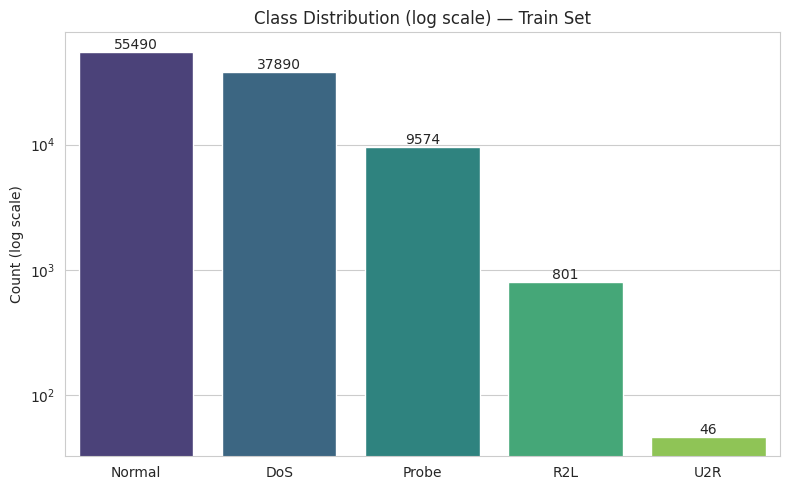

Normal:U2R ratio ≈ 1206 : 1


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

order = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train, x='attack_category', order=order, palette='viridis')
ax.set_yscale('log')  # log scale makes R2L/U2R visible next to Normal/DoS
plt.title('Class Distribution (log scale) — Train Set')
plt.ylabel('Count (log scale)')
plt.xlabel('')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print(f"Normal:U2R ratio ≈ {cat_counts['Normal'] / cat_counts['U2R']:.0f} : 1")

## 4. Categorical Features

In [12]:
for col in ['protocol_type', 'flag']:
    print(f'--- {col} ---')
    print((train[col].value_counts(normalize=True) * 100).round(1))
    print()

print('service: number of unique categories =', train['service'].nunique())
print(train['service'].value_counts().head(10))

--- protocol_type ---
protocol_type
tcp     81.5
udp     11.9
icmp     6.6
Name: proportion, dtype: float64

--- flag ---
flag
SF        59.4
S0        27.7
REJ        8.9
RSTR       1.9
RSTO       1.2
S1         0.3
SH         0.2
S2         0.1
RSTOS0     0.1
OTH        0.0
S3         0.0
Name: proportion, dtype: float64

service: number of unique categories = 69
service
http        33263
private     17975
domain_u     7458
smtp         5969
ftp_data     5645
eco_i        3781
other        3590
ecr_i        2546
telnet       1922
finger       1480
Name: count, dtype: int64


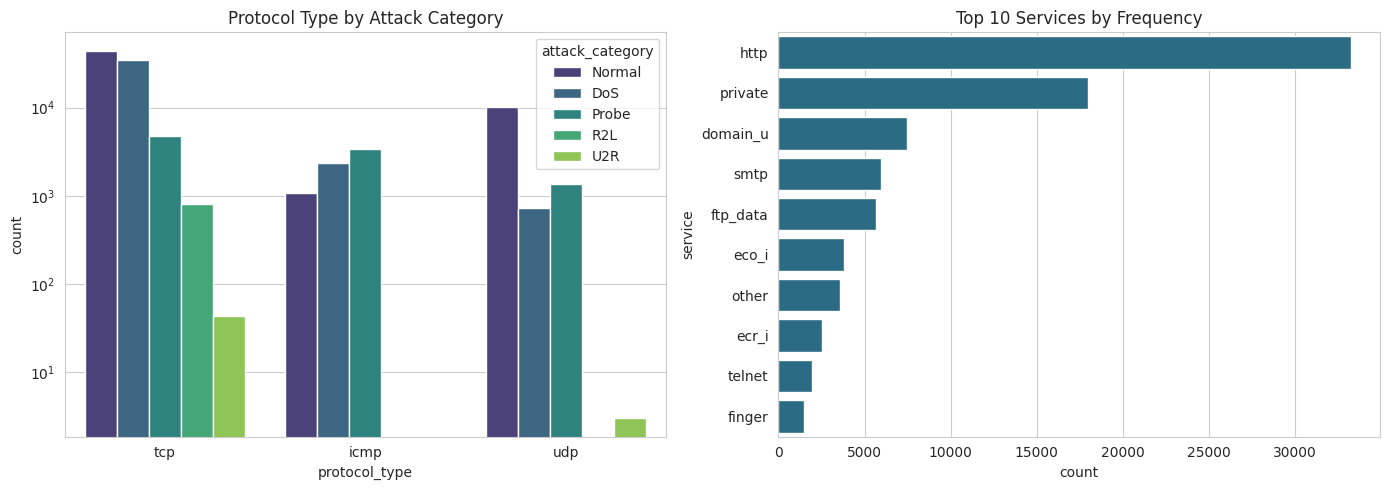

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=train, x='protocol_type', hue='attack_category', hue_order=order, ax=axes[0], palette='viridis')
axes[0].set_title('Protocol Type by Attack Category')
axes[0].set_yscale('log')

top_services = train['service'].value_counts().head(10).index
sns.countplot(data=train[train['service'].isin(top_services)], y='service',
              order=top_services, ax=axes[1], color='#1C7293')
axes[1].set_title('Top 10 Services by Frequency')

plt.tight_layout()
plt.show()

## 5. Numeric Feature Relationships

In [14]:
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
corr = train[numeric_cols].corr()

# Find highly correlated pairs (|r| > 0.95), excluding self-correlation
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.95:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation']) \
                  .sort_values('Correlation', key=abs, ascending=False)
high_corr_df

,Feature 1,Feature 2,Correlation
0,num_compromised,num_root,0.999
1,serror_rate,srv_serror_rate,0.993
6,rerror_rate,srv_rerror_rate,0.990
5,srv_serror_rate,dst_host_srv_serror_rate,0.986
9,dst_host_serror_rate,dst_host_srv_serror_rate,0.985
3,serror_rate,dst_host_srv_serror_rate,0.981
2,serror_rate,dst_host_serror_rate,0.979
4,srv_serror_rate,dst_host_serror_rate,0.978
8,srv_rerror_rate,dst_host_srv_rerror_rate,0.971
7,rerror_rate,dst_host_srv_rerror_rate,0.965


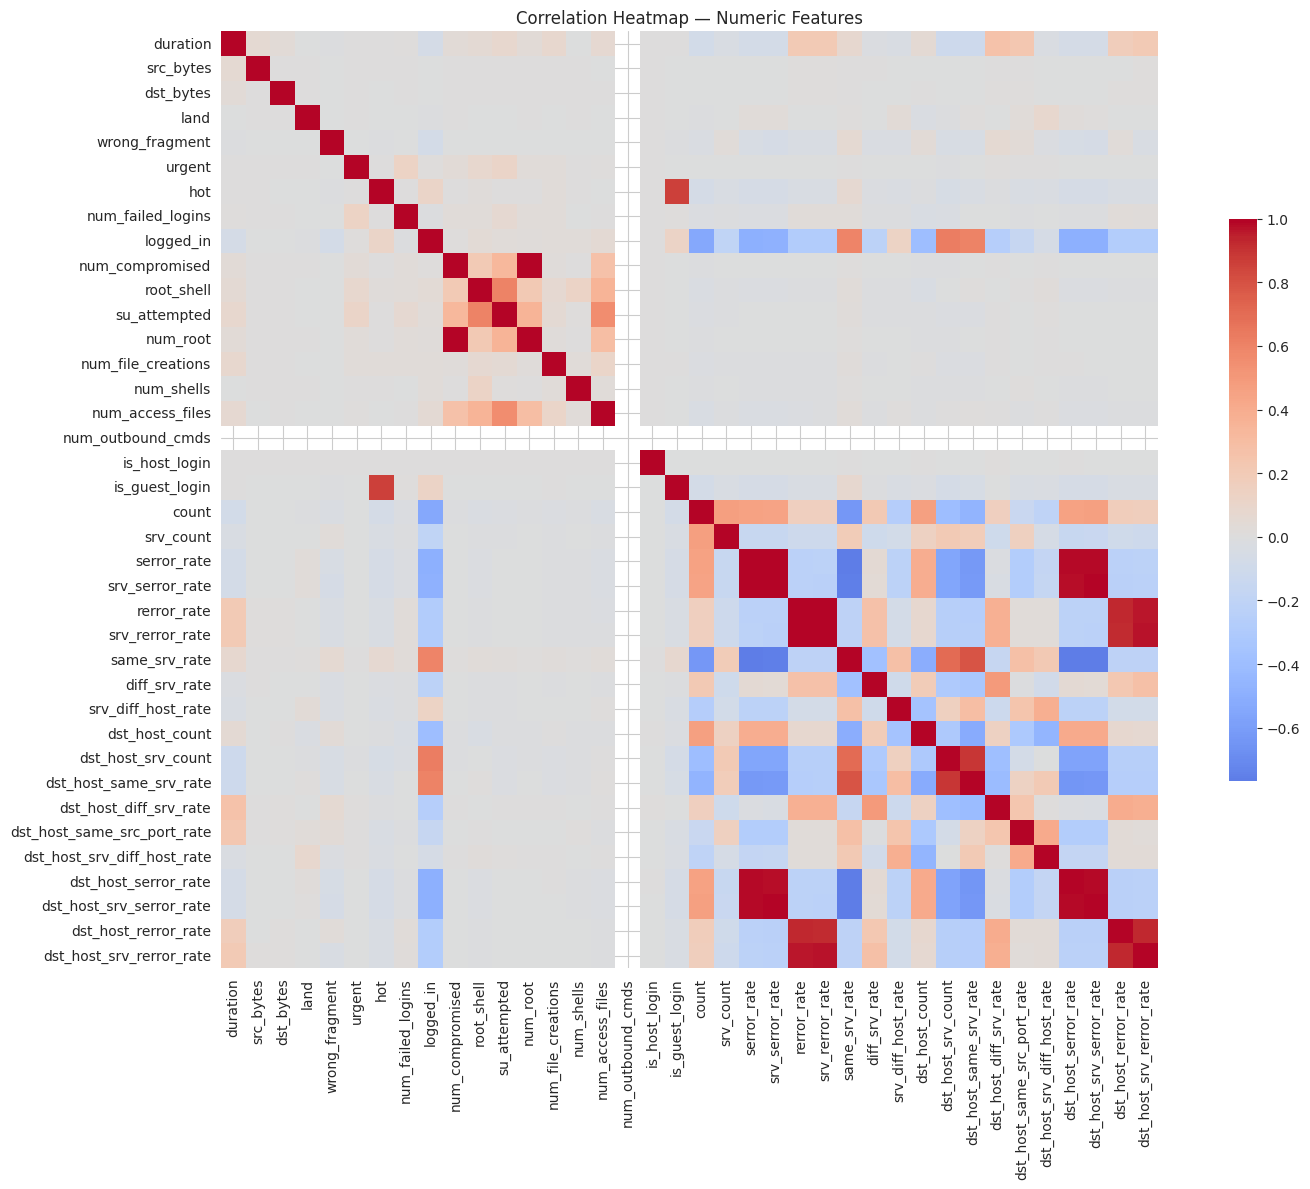

In [15]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.6})
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

## 6. Feature Behavior by Class

/tmp/ipykernel_1048/3555903605.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='attack_category', y=np.log1p(train[col]), order=order, ax=ax, palette='viridis')
/tmp/ipykernel_1048/3555903605.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='attack_category', y=np.log1p(train[col]), order=order, ax=ax, palette='viridis')
/tmp/ipykernel_1048/3555903605.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='attack_category', y=np.log1p(train[col]), order=order, ax=ax, palette='viridis')


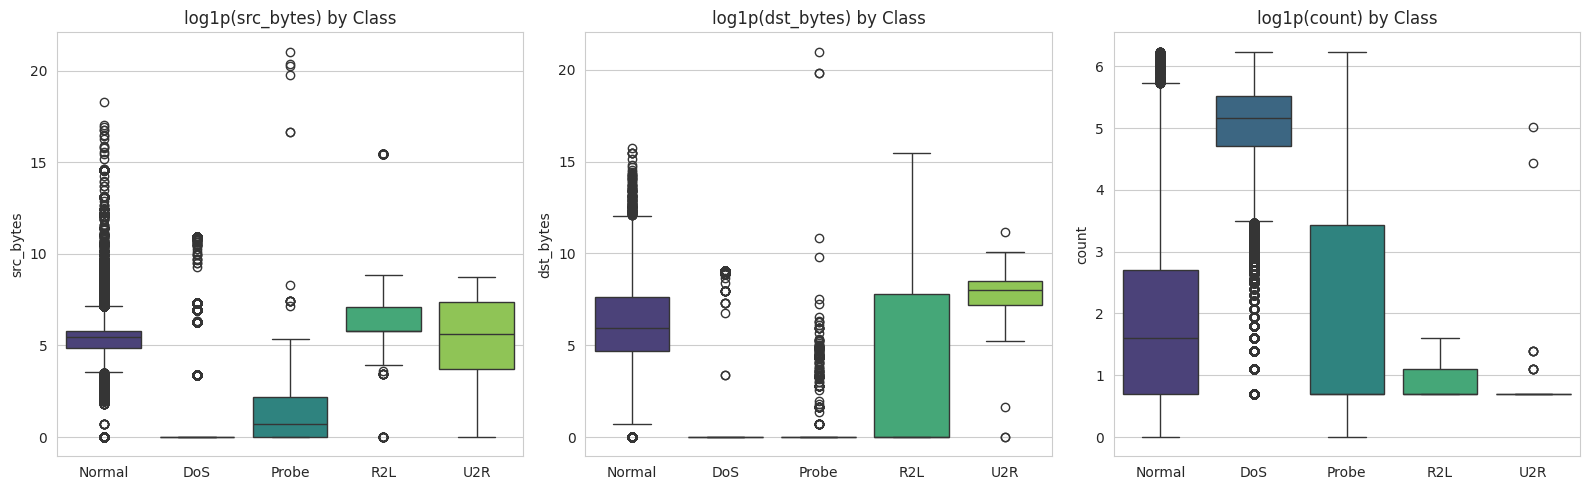

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['src_bytes', 'dst_bytes', 'count']):
    sns.boxplot(data=train, x='attack_category', y=np.log1p(train[col]), order=order, ax=ax, palette='viridis')
    ax.set_title(f'log1p({col}) by Class')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1048/1886859400.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='attack_category', y='serror_rate', order=order, palette='viridis')


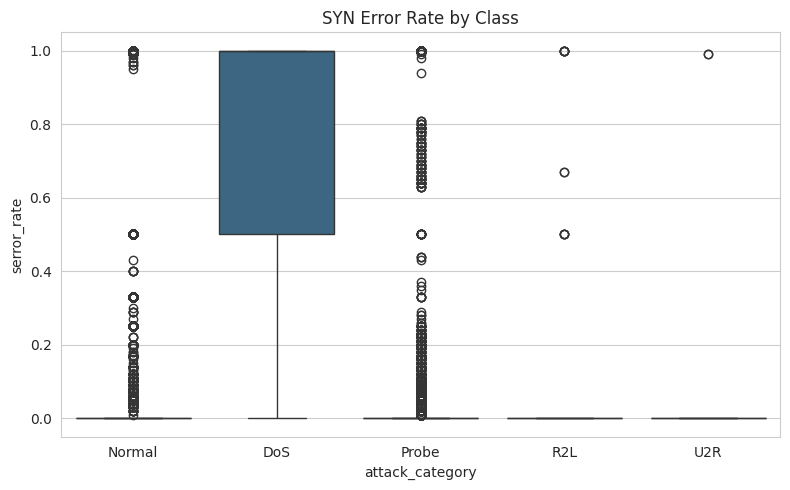

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train, x='attack_category', y='serror_rate', order=order, palette='viridis')
plt.title('SYN Error Rate by Class')
plt.tight_layout()
plt.show()

## 7. Implications for Modeling (summary)

| Finding | Implication |
|---|---|
| Severe class imbalance (R2L/U2R) | Stratified sampling, class-weighting, SMOTE; report per-class P/R/F1 — never accuracy alone |
| Highly correlated features (\|r\| > 0.95) | Tree ensembles tolerate this; SVM/KNN/Logistic Regression benefit from de-duplication or PCA |
| `service` has 69 categories | Frequency/target encoding rather than plain one-hot |
| Skewed numeric features (bytes, counts) | `log1p` transform, or use scale-robust tree models as a baseline |
| `num_outbound_cmds` constant | Drop — no signal |

**Next steps:** encode categoricals, drop/derive redundant features, scale numeric features,
handle class imbalance, then train baseline models (Decision Tree, Random Forest, Logistic
Regression, KNN, Naive Bayes) followed by advanced models (XGBoost, SVM, Neural Network).


## 8. Preprocessing for Modeling
Prepare a binary target (`Normal` vs `Attack`) for the main classification task, encode
categorical features, drop the constant column, and scale numeric features. We keep the
70/15/15 splits already provided in the dataset (no re-splitting).

In [18]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Binary target: Normal vs Attack (used for the main classifier + ROC-AUC)
for df in (train, val, test):
    df['binary_label'] = np.where(df['label'] == 'normal', 'Normal', 'Attack')

# Drop zero-variance column identified during EDA
drop_cols = [c for c in constant_cols if c in train.columns]
print('Dropping constant column(s):', drop_cols)

feature_cols = [c for c in train.columns
                if c not in ['label', 'attack_category', 'binary_label'] + drop_cols]
categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [c for c in feature_cols if c not in categorical_features]

print('Total features used:', len(feature_cols))
print('Categorical:', categorical_features)

Dropping constant column(s): ['num_outbound_cmds']
Total features used: 40
Categorical: ['protocol_type', 'service', 'flag']


In [19]:
# Label-encode categoricals on TRAIN only, then apply the same mapping to val/test.
# Unseen categories in val/test are mapped to a new 'unseen' bucket so the pipeline
# doesn't crash on categories that only appear outside the training split.
encoders = {}
X_train, X_val, X_test = train[feature_cols].copy(), val[feature_cols].copy(), test[feature_cols].copy()

for col in categorical_features:
    le = LabelEncoder()
    le.fit(list(X_train[col].unique()) + ['unseen'])
    encoders[col] = le
    for X, name in [(X_train, 'train'), (X_val, 'val'), (X_test, 'test')]:
        X[col] = X[col].where(X[col].isin(le.classes_), 'unseen')
        X[col] = le.transform(X[col])

# Scale numeric features (fit on train only)
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val[numeric_features] = scaler.transform(X_val[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# Targets
y_train_bin = (train['binary_label'] == 'Attack').astype(int)
y_val_bin   = (val['binary_label']   == 'Attack').astype(int)
y_test_bin  = (test['binary_label']  == 'Attack').astype(int)

y_train_multi = train['attack_category']
y_val_multi   = val['attack_category']
y_test_multi  = test['attack_category']

print('X_train:', X_train.shape, ' X_val:', X_val.shape, ' X_test:', X_test.shape)

X_train: (103801, 40)  X_val: (22172, 40)  X_test: (22544, 40)


## 9. Algorithm Implementation
Two supervised ensemble models are trained on the binary task (Normal vs Attack), which is
the main comparison in this project:
- **Random Forest** — bagging of independent decision trees, majority vote.
- **Gradient-Boosted Trees** (`GradientBoostingClassifier`) — trees built sequentially, each
  one correcting the errors of the previous one.

The validation split is used for model selection / sanity-checking; the test split is used
only once, for the final comparison in Section 10.

In [20]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import time

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=None, n_jobs=-1, random_state=42, class_weight='balanced'
)

t0 = time.time()
rf_model.fit(X_train, y_train_bin)
print(f'Random Forest trained in {time.time() - t0:.1f}s')

Random Forest trained in 26.3s


In [21]:
gbt_model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42
)

t0 = time.time()
gbt_model.fit(X_train, y_train_bin)
print(f'Gradient-Boosted Trees trained in {time.time() - t0:.1f}s')

Gradient-Boosted Trees trained in 51.3s


In [22]:
# Quick check on the validation split before touching test
from sklearn.metrics import accuracy_score, f1_score

for name, model in [('Random Forest', rf_model), ('Gradient-Boosted Trees', gbt_model)]:
    val_pred = model.predict(X_val)
    print(f'{name}: validation accuracy={accuracy_score(y_val_bin, val_pred):.4f}, '
          f'F1={f1_score(y_val_bin, val_pred):.4f}')

Random Forest: validation accuracy=0.9989, F1=0.9988
Gradient-Boosted Trees: validation accuracy=0.9982, F1=0.9980


## 10. Model Evaluation and Comparison (Test Set)
Metrics used, as specified in the abstract: **Accuracy, Precision, Recall, F1-score,
Confusion Matrix, and ROC-AUC.**

In [23]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve, classification_report)

results = []
roc_data = {}

for name, model in [('Random Forest', rf_model), ('Gradient-Boosted Trees', gbt_model)]:
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_bin, pred),
        'Precision': precision_score(y_test_bin, pred),
        'Recall': recall_score(y_test_bin, pred),
        'F1-score': f1_score(y_test_bin, pred),
        'ROC-AUC': roc_auc_score(y_test_bin, proba),
    })
    roc_data[name] = roc_curve(y_test_bin, proba)

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Random Forest,0.7770,0.9671,0.6297,0.7628,0.9662
Gradient-Boosted Trees,0.8176,0.9692,0.7019,0.8142,0.9653


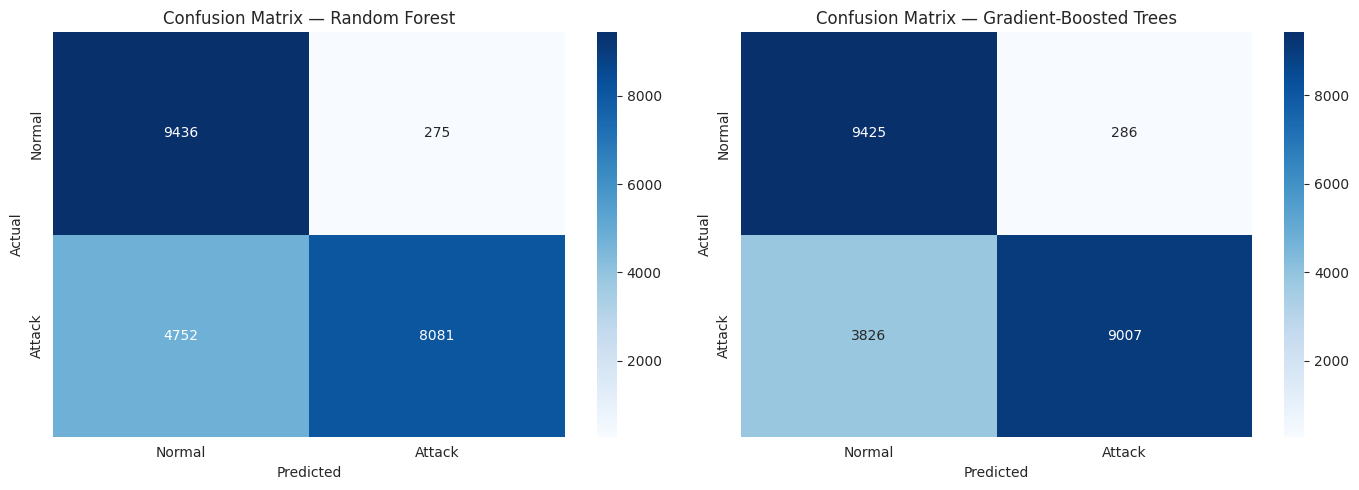

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [('Random Forest', rf_model), ('Gradient-Boosted Trees', gbt_model)]):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test_bin, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

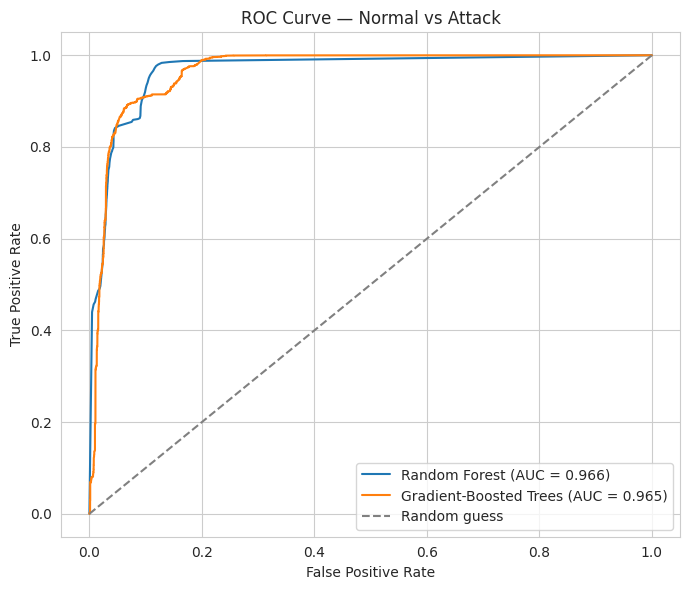

In [25]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, _) in roc_data.items():
    auc = results_df.loc[name, 'ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Normal vs Attack')
plt.legend()
plt.tight_layout()
plt.show()

### Per-class performance (multiclass attack categories)
The binary metrics above answer *"is this traffic malicious?"*. Because the class
distribution is heavily imbalanced (see Section 3), we also report per-class Precision/
Recall/F1 for Normal/DoS/Probe/R2L/U2R using the Random Forest predictions, retrained on
the multiclass target, so that rare classes like R2L and U2R aren't hidden by overall accuracy.

In [27]:
rf_multi = RandomForestClassifier(
    n_estimators=200, n_jobs=-1, random_state=42, class_weight='balanced'
)
rf_multi.fit(X_train, y_train_multi)
multi_pred = rf_multi.predict(X_test)

# Filter out NaN values from y_test_multi and multi_pred
# The TypeError occurs because y_test_multi contains both strings and float (NaN) types.
# This happens when some original 'label' values were not in 'attack_map'.
mask = y_test_multi.notna()
y_test_multi_filtered = y_test_multi[mask]
multi_pred_filtered = multi_pred[mask]

print(classification_report(y_test_multi_filtered, multi_pred_filtered, digits=3))

              precision    recall  f1-score   support

         DoS      0.988     0.991     0.989      5741
      Normal      0.808     0.972     0.883      9711
       Probe      0.823     1.000     0.903      1106
         R2L      0.875     0.003     0.006      2199
         U2R      0.000     0.000     0.000        37

    accuracy                          0.864     18794
   macro avg      0.699     0.593     0.556     18794
weighted avg      0.870     0.864     0.812     18794



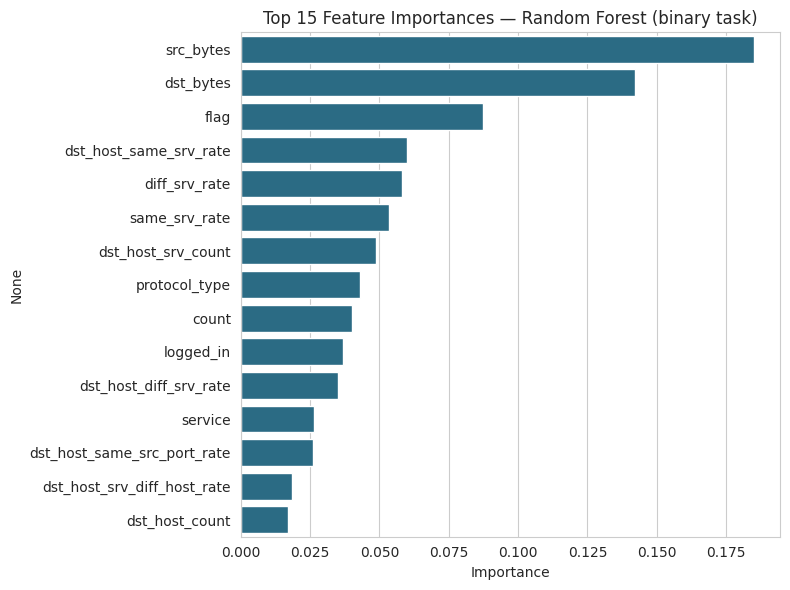

In [28]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols) \
                .sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color='#1C7293')
plt.title('Top 15 Feature Importances — Random Forest (binary task)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 11. Conclusion
Both ensemble models are compared on the held-out test split using the metrics table in
Section 10. Fill in the specific numbers from your run in the write-up, e.g.:

- Which model had the higher ROC-AUC / F1-score, and by how much.
- Whether Gradient-Boosted Trees' sequential error-correction gave it an edge on the rarer
  R2L/U2R classes compared to Random Forest's majority vote.
- Which features (Section 10 importance plot) drove the decision the most, and whether that
  matches domain intuition (e.g. `same_srv_rate`, `serror_rate`, `dst_host_srv_count`).

**Next steps beyond this review:** hyperparameter tuning (grid/random search), trying
XGBoost/LightGBM as a stronger gradient-boosting baseline, and testing SMOTE for the U2R/R2L
minority classes.